# Brain Tumor Segmentation with U-Net

This notebook trains a U-Net to segment brain tumors from MRI slices —
given a scan, it predicts a pixel-level mask of where the tumor is, rather
than just a yes/no classification.

**Dataset:** [LGG MRI Segmentation](https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation) (Kaggle) — 3,929 MRI slices, each paired with a radiologist-drawn tumor mask.

**Result:** Test Dice score of **0.75** on scans held out from training.

---

## Setup

In [ ]:
!pip install -q kaggle > /dev/null 2>&1

In [ ]:
import os

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, backend as K

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 30
TEST_SIZE = 0.2
VAL_SPLIT = 0.1

DATA_DIR = "/content/lgg_dataset/lgg-mri-segmentation/kaggle_3m/"
KAGGLE_DATASET = "mateuszbuda/lgg-mri-segmentation"


## Data

The dataset ships as one folder per patient, each containing paired
`.tif` files — an MRI slice and its `_mask` counterpart.

Credentials are entered via `getpass` rather than uploading `kaggle.json` —
uploading the file causes Colab to echo its raw contents (including the
key) into the cell output, which is easy to accidentally commit. `getpass`
never prints what's typed and nothing sensitive ends up on disk or in
this notebook. Get a token at Kaggle → Settings → API → Create New Token.

In [ ]:
import getpass

os.environ["KAGGLE_USERNAME"] = getpass.getpass("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass.getpass("Kaggle API key: ")

In [ ]:
!kaggle datasets download -d {KAGGLE_DATASET} -q
!unzip -q -o lgg-mri-segmentation.zip -d lgg_dataset

In [1]:
def build_file_lists(data_dir):
    """Walk the dataset directory and pair every MRI slice with its mask."""
    image_paths, mask_paths = [], []

    for root, _, filenames in os.walk(data_dir):
        for name in filenames:
            if name.endswith(".tif") and "_mask" not in name:
                img_path = os.path.join(root, name)
                mask_path = os.path.join(root, name.replace(".tif", "_mask.tif"))
                if os.path.exists(mask_path):
                    image_paths.append(img_path)
                    mask_paths.append(mask_path)

    return image_paths, mask_paths


image_paths, mask_paths = build_file_lists(DATA_DIR)
print(f"{len(image_paths)} image/mask pairs found")

3929 image/mask pairs found


A quick look at one raw pair, before any preprocessing:

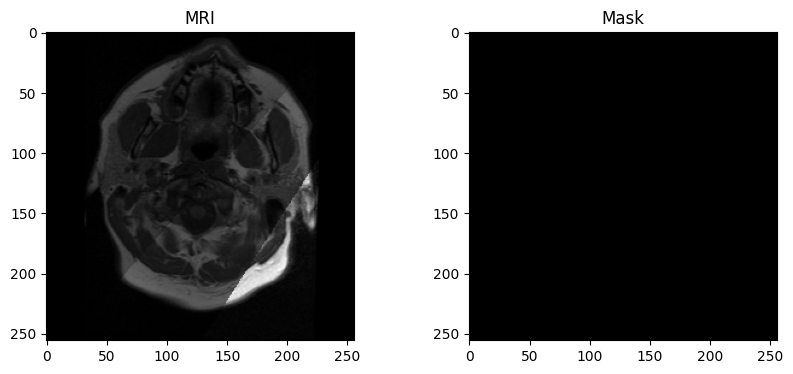

In [1]:
img = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("MRI"); axes[0].axis("off")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Mask"); axes[1].axis("off")
plt.show()

## Preprocessing

Every slice is resized to 128×128 and scaled to `[0, 1]`. Masks are
thresholded to strictly binary after resizing, since interpolation can
introduce in-between pixel values along the mask edges.

In [1]:
def load_dataset(image_paths, mask_paths, img_size=IMG_SIZE):
    """Load, resize, and normalize every image/mask pair."""
    images, masks = [], []

    for img_path, mask_path in zip(image_paths, mask_paths):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, img_size) / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, img_size)
        mask = (mask / 255.0 > 0.5).astype(np.float32)

        images.append(img)
        masks.append(mask)

    return np.array(images)[..., np.newaxis], np.array(masks)[..., np.newaxis]


images, masks = load_dataset(image_paths, mask_paths)
print(f"images: {images.shape}   masks: {masks.shape}")

images: (3929, 128, 128, 1)   masks: (3929, 128, 128, 1)


In [1]:
train_images, test_images, train_masks, test_masks = train_test_split(
    images, masks, test_size=TEST_SIZE, random_state=42
)

print(f"train: {train_images.shape[0]} slices   test: {test_images.shape[0]} slices")

train: 3143 slices   test: 786 slices


## Why Dice, not accuracy

Tumor pixels are a small minority of the dataset — most of any slice is
background or healthy tissue, and a large share of slices have no tumor at
all. A model that predicts "background" everywhere already scores ~98%
accuracy by default, which makes accuracy nearly useless for judging this
task.

Dice measures direct overlap between the predicted mask and the true mask:

$$\text{Dice} = \frac{2 \times |\text{prediction} \cap \text{truth}|}{|\text{prediction}| + |\text{truth}|}$$

A model that predicts nothing scores 0 on Dice, no matter how "accurate"
it looks pixel-wise. It's tracked here as a training metric and used as
the real evaluation score throughout.

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    """Dice similarity coefficient between true and predicted masks."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

## Model: U-Net

U-Net compresses the image down through an encoder, then expands it back
up through a decoder — the "U" shape the name refers to. Skip connections
carry fine spatial detail directly from encoder to decoder at matching
resolutions, which is what lets the output be a sharp mask instead of a
blurry approximation.

This is a compact version: two downsampling steps, a bottleneck, and two
upsampling steps, with filter counts of 64 → 128 → 256.

In [1]:
def build_unet(input_shape=(128, 128, 1)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(inputs)
    c1 = layers.Conv2D(64, 3, activation="relu", padding="same")(c1)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = layers.Conv2D(128, 3, activation="relu", padding="same")(p1)
    c2 = layers.Conv2D(128, 3, activation="relu", padding="same")(c2)
    p2 = layers.MaxPooling2D(2)(c2)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation="relu", padding="same")(p2)
    b = layers.Conv2D(256, 3, activation="relu", padding="same")(b)

    # Decoder
    u2 = layers.UpSampling2D(2)(b)
    u2 = layers.Conv2D(128, 3, activation="relu", padding="same")(u2)
    u2 = layers.Concatenate()([u2, c2])
    c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(u2)
    c3 = layers.Conv2D(128, 3, activation="relu", padding="same")(c3)

    u1 = layers.UpSampling2D(2)(c3)
    u1 = layers.Conv2D(64, 3, activation="relu", padding="same")(u1)
    u1 = layers.Concatenate()([u1, c1])
    c4 = layers.Conv2D(64, 3, activation="relu", padding="same")(u1)
    c4 = layers.Conv2D(64, 3, activation="relu", padding="same")(c4)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c4)
    return models.Model(inputs, outputs, name="unet")


K.clear_session()
model = build_unet(input_shape=(*IMG_SIZE, 1))
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", dice_coef])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 

## Training

In [1]:
history = model.fit(
    train_images, train_masks,
    validation_split=VAL_SPLIT,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
)

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 85s 344ms/step - accuracy: 0.9844 - dice_coef: 0.0732 - loss: 0.0639 - val_accuracy: 0.9891 - val_dice_coef: 0.0860 - val_loss: 0.0385
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.9893 - dice_coef: 0.1101 - loss: 0.0382 - val_accuracy: 0.9891 - val_dice_coef: 0.1012 - val_loss: 0.0377
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 31s 176ms/step - accuracy: 0.9893 - dice_coef: 0.1320 - loss: 0.0370 - val_accuracy: 0.9891 - val_dice_coef: 0.1333 - val_loss: 0.0351
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.9897 - dice_coef: 0.1635 - loss: 0.0349 - val_accuracy: 0.9896 - val_dice_coef: 0.1602 - val_loss: 0.0342
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - accuracy: 0.9901 - dice_coef: 0.1795 - loss: 0.0341 - val_accuracy: 0.9896 - val_dice_coef: 0.1481 - val_loss: 0.0353
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 32s 180ms/step - accuracy: 0.9905 - dice_coef: 0.2160 - loss: 0.0330 - val_accuracy: 

## Evaluation

In [1]:
test_loss, test_acc, test_dice = model.evaluate(test_images, test_masks)
print(f"test loss:     {test_loss:.4f}")
print(f"test accuracy: {test_acc:.4f}  (not meaningful alone — see note above)")
print(f"test dice:     {test_dice:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 489ms/step - accuracy: 0.9963 - dice_coef: 0.7541 - loss: 0.0137
test loss:     0.0137
test accuracy: 0.9963  (not meaningful alone — see note above)
test dice:     0.7541


In [ ]:
predictions = model.predict(test_images)
pred_masks = (predictions > 0.5).astype("uint8")

## Results

**Training curves** — training and validation Dice climbing together is the signal the model is learning general patterns, not memorizing training slices.

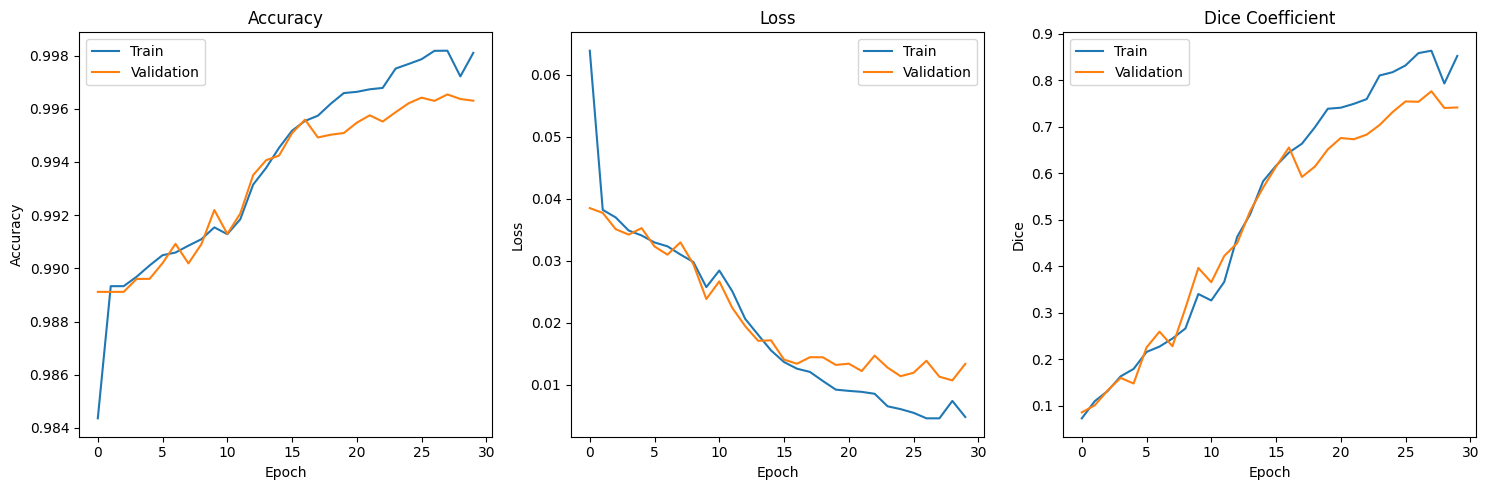

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(
    axes, ["accuracy", "loss", "dice_coef"], ["Accuracy", "Loss", "Dice"]
):
    ax.plot(history.history[metric], label="train")
    ax.plot(history.history[f"val_{metric}"], label="val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()

plt.tight_layout()
plt.show()

**Predicted mask** — a held-out test slice that actually contains a tumor, so the comparison means something.

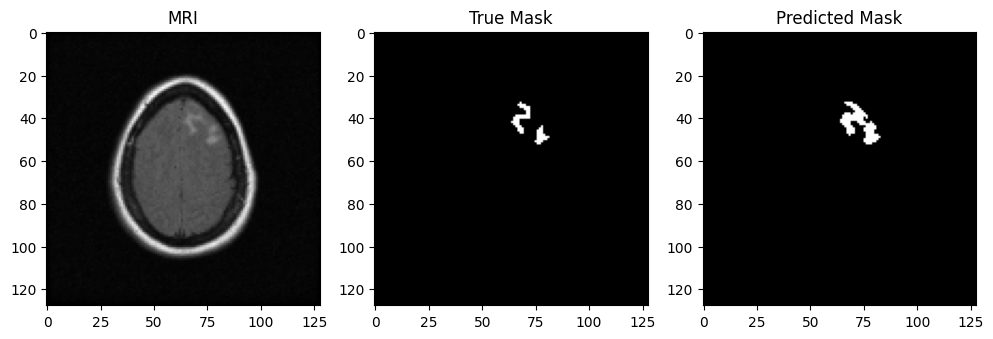

In [1]:
tumor_idx = next(i for i in range(len(test_masks)) if test_masks[i].sum() > 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_images[tumor_idx].squeeze(), cmap="gray"); axes[0].set_title("MRI")
axes[1].imshow(test_masks[tumor_idx].squeeze(), cmap="gray"); axes[1].set_title("True Mask")
axes[2].imshow(pred_masks[tumor_idx].squeeze(), cmap="gray"); axes[2].set_title("Predicted Mask")
for ax in axes:
    ax.axis("off")
plt.show()

**Tumor overlay** — the predicted mask painted directly on the scan, closer to how this would actually be reviewed in practice.

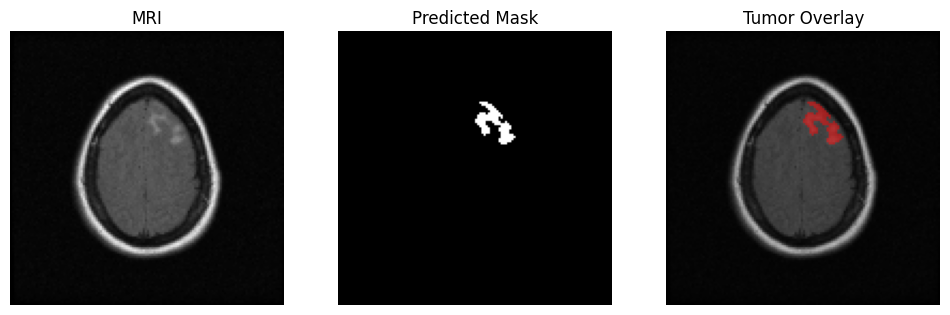

In [1]:
def overlay_mask(image, mask, alpha=0.5):
    """Paint a predicted mask in red on top of the grayscale MRI."""
    rgb = cv2.cvtColor((image * 255).astype("uint8"), cv2.COLOR_GRAY2RGB)
    overlay = rgb.copy()
    overlay[mask > 0] = [255, 0, 0]
    return cv2.addWeighted(rgb, 1 - alpha, overlay, alpha, 0)


img = test_images[tumor_idx].squeeze()
mask = pred_masks[tumor_idx].squeeze()
overlay = overlay_mask(img, mask)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap="gray"); axes[0].set_title("MRI")
axes[1].imshow(mask, cmap="gray"); axes[1].set_title("Predicted Mask")
axes[2].imshow(overlay); axes[2].set_title("Tumor Overlay")
for ax in axes:
    ax.axis("off")
plt.show()

## Limitations

- Trained on plain binary cross-entropy — no Dice-aware loss term, so the
  class imbalance is never directly corrected during training.
- Trained on the full dataset, including slices with no tumor, rather than
  filtering to tumor-only slices.
- Grayscale input only.
- A shallow, 2-level U-Net; a deeper 4-level version is the more typical
  choice for this task and would likely score higher.